# 02 — Feature engineering analysis

This notebook validates and analyses all feature engineering steps defined in the PRD (Section 3).

Covers:
1. Skewness analysis of numerical features + log transform
2. Engineered feature validation (TotalSF, HouseAge, RemodAge, TotalBaths, HasPool, TotalPorchSF)
3. Ordinal encoding verification
4. Correlation improvement: raw vs engineered features
5. VIF (variance inflation factor) — detecting multicollinearity
6. Feature importance preview with a quick Random Forest

In [4]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data import load_train, remove_outliers, split_features_target
from features import full_preprocess, ORDINAL_MAP

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)

In [5]:
train_df = load_train()
train_df = remove_outliers(train_df)
X_raw, y = split_features_target(train_df)
X, medians = full_preprocess(X_raw.copy())
y_aligned = y.loc[X.index] if hasattr(y, 'loc') else y

print(f'Raw features:        {X_raw.shape[1]}')
print(f'After engineering:   {X.shape[1]}')
print(f'New features added:  {X.shape[1] - X_raw.shape[1]}')

Loaded train.csv — 2930 rows, 82 columns
Removed 3 outliers based on Gr Liv Area and SalePrice
Missing values after imputation: 0
Engineered features added: TotalSF, HouseAge, RemodAge, TotalBaths, HasPool, TotalPorchSF
Raw features:        81
After engineering:   87
New features added:  6


## 1. Skewness analysis — numerical features

Features with |skew| > 0.75: 21


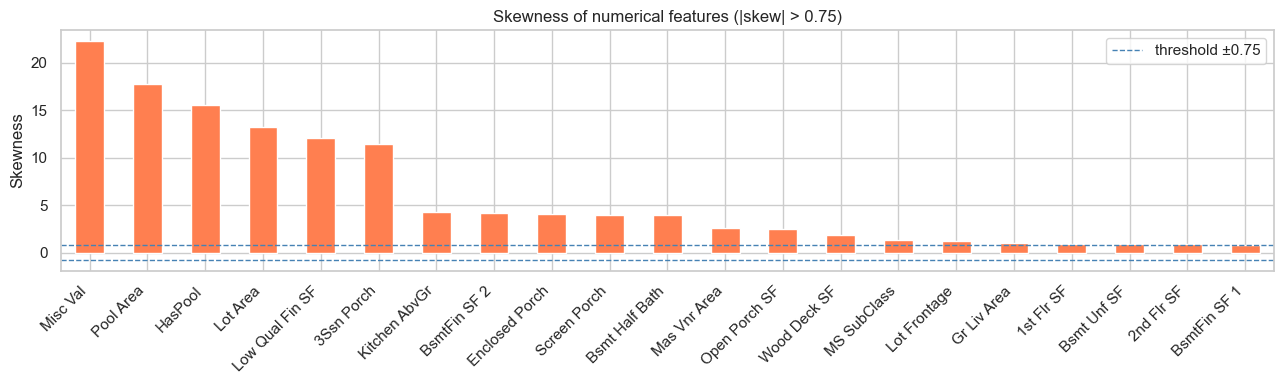

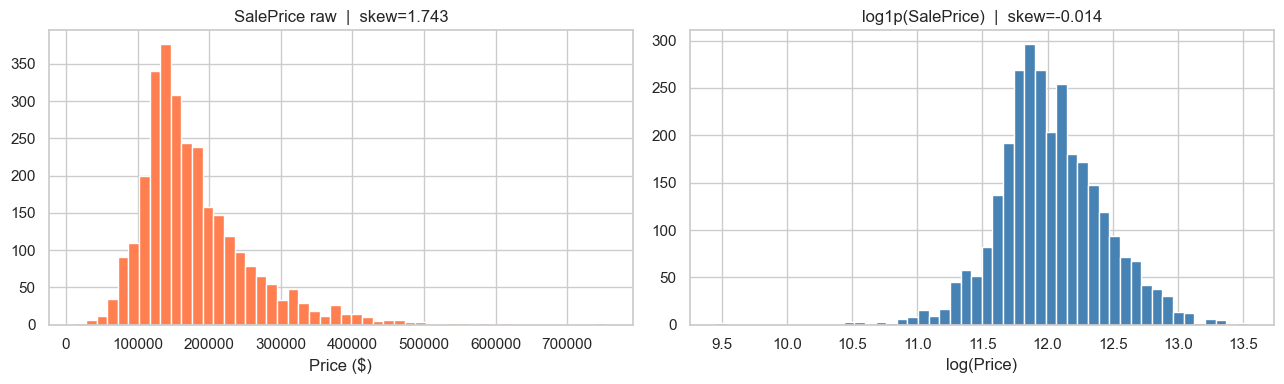

In [ ]:
num_cols = X.select_dtypes(include=[np.number]).columns
skew = X[num_cols].skew().sort_values(ascending=False)
high_skew = skew[skew.abs() > 0.75]
print(f'Features with |skew| > 0.75: {len(high_skew)}')

plt.figure(figsize=(13, 4))
high_skew.plot(kind='bar', color='coral', edgecolor='white')
plt.axhline(0.75, color='steelblue', linestyle='--', linewidth=1, label='threshold ±0.75')
plt.axhline(-0.75, color='steelblue', linestyle='--', linewidth=1)
plt.title('Skewness of numerical features (|skew| > 0.75)')
plt.ylabel('Skewness')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/skewness_bar.png')
plt.show()

# Target: raw vs log
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(y, bins=50, edgecolor='white', color='coral')
axes[0].set_title(f'SalePrice raw  |  skew={y.skew():.3f}')
axes[0].set_xlabel('Price ($)')
y_log = np.log1p(y)
axes[1].hist(y_log, bins=50, edgecolor='white', color='steelblue')
axes[1].set_title(f'log1p(SalePrice)  |  skew={y_log.skew():.3f}')
axes[1].set_xlabel('log(Price)')
plt.tight_layout()
plt.savefig('../reports/figures/target_skewness_log.png')
plt.show()

## 2. Engineered feature validation

  TotalSF            OK
  HouseAge           OK
  RemodAge           OK
  TotalBaths         OK
  HasPool            OK
  TotalPorchSF       OK

       TotalSF  HouseAge  RemodAge  TotalBaths  HasPool  TotalPorchSF
count   2927.0    2924.0    2924.0      2927.0  2927.00        2927.0
mean       0.0       0.0       0.0         0.0     0.00           0.0
std        0.0       0.0       0.0         0.0     0.06           0.0
min        0.0       0.0       0.0         0.0     0.00           0.0
25%        0.0       0.0       0.0         0.0     0.00           0.0
50%        0.0       0.0       0.0         0.0     0.00           0.0
75%        0.0       0.0       0.0         0.0     0.00           0.0
max        0.0       0.0       0.0         0.0     1.00           0.0


c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


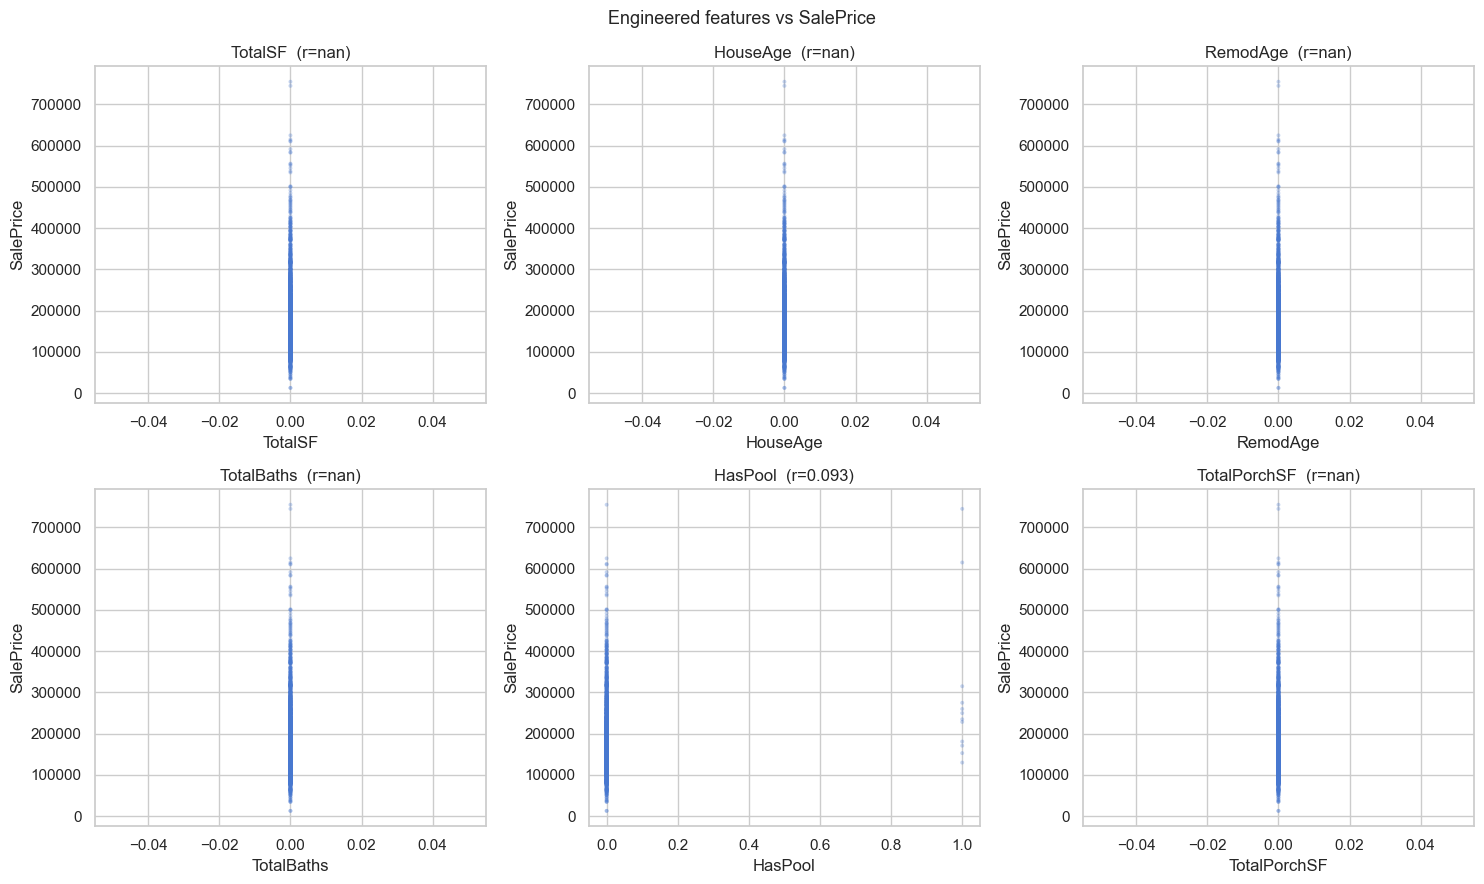

In [ ]:
eng_feats = ['TotalSF', 'HouseAge', 'RemodAge', 'TotalBaths', 'HasPool', 'TotalPorchSF']

for f in eng_feats:
    print(f'  {f:<18} {"OK" if f in X.columns else "MISSING"}')

print()
print(X[eng_feats].describe().round(2))

# Scatter plots vs SalePrice
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, feat in zip(axes.flatten(), eng_feats):
    ax.scatter(X[feat], y_aligned, alpha=0.3, s=8, edgecolors='none')
    ax.set_title(f'{feat}  (r={X[feat].corr(y_aligned):.3f})')
    ax.set_xlabel(feat)
    ax.set_ylabel('SalePrice')
plt.suptitle('Engineered features vs SalePrice', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/engineered_features_scatter.png')
plt.show()

## 3. Ordinal encoding verification

In [ ]:
print('Ordinal mapping:')
for k, v in sorted(ORDINAL_MAP.items(), key=lambda x: x[1], reverse=True):
    print(f'  {k:<8} -> {v}')

if 'KitchenQual' in X.columns:
    print(f'\nKitchenQual dtype: {X["KitchenQual"].dtype}')
    print(f'Unique values: {sorted(X["KitchenQual"].unique())}')
    fig, ax = plt.subplots(figsize=(7, 4))
    groups = {v: y_aligned[X['KitchenQual'] == v] for v in sorted(X['KitchenQual'].unique())}
    ax.boxplot(groups.values(), labels=[f'Level {k}' for k in groups.keys()])
    ax.set_title('KitchenQual (encoded) vs SalePrice')
    ax.set_xlabel('Quality level (0=None, 1=Po ... 5=Ex)')
    ax.set_ylabel('SalePrice ($)')
    plt.tight_layout()
    plt.savefig('../reports/figures/kitchenqual_boxplot.png')
    plt.show()

Ordinal mapping:
  Ex       -> 5
  Gd       -> 4
  TA       -> 3
  Fa       -> 2
  Po       -> 1
  None     -> 0


## 4. Correlation: raw vs engineered

Top 10 raw feature correlations:
Overall Qual      0.8026
Gr Liv Area       0.7271
Total Bsmt SF     0.6606
Garage Cars       0.6485
1st Flr SF        0.6456
Garage Area       0.6444
Year Built        0.5589
Full Bath         0.5464
Year Remod/Add    0.5334
Garage Yr Blt     0.5275

Top 10 after engineering:
Overall Qual      0.8026
Gr Liv Area       0.7271
Total Bsmt SF     0.6605
Garage Cars       0.6484
1st Flr SF        0.6456
Garage Area       0.6444
Year Built        0.5589
Full Bath         0.5464
Year Remod/Add    0.5334
Garage Yr Blt     0.5093


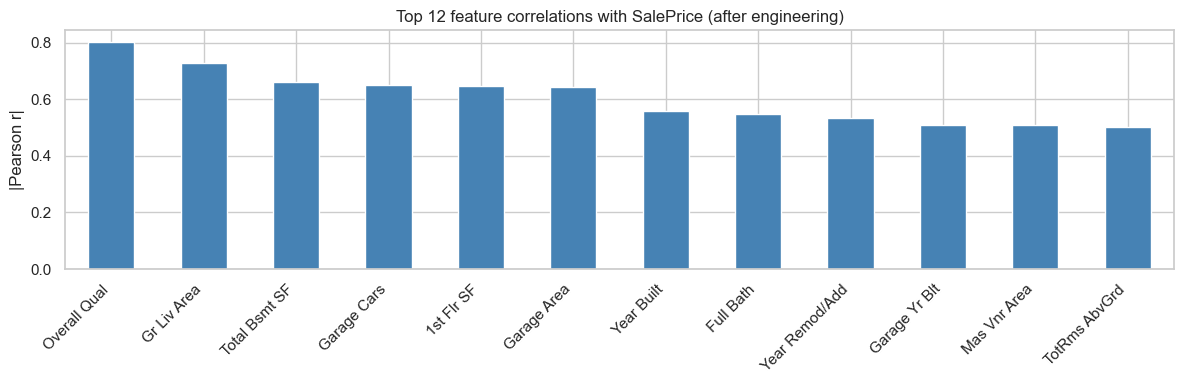

In [ ]:
raw_corr = X_raw.select_dtypes(include=[np.number]).corrwith(y).abs().sort_values(ascending=False)
eng_corr = X.select_dtypes(include=[np.number]).corrwith(y_aligned).abs().sort_values(ascending=False)

print('Top 10 raw feature correlations:')
print(raw_corr.head(10).round(4).to_string())
print()
print('Top 10 after engineering:')
print(eng_corr.head(10).round(4).to_string())

plt.figure(figsize=(12, 4))
eng_corr.head(12).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 12 feature correlations with SalePrice (after engineering)')
plt.ylabel('|Pearson r|')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/feature_correlation_bar.png')
plt.show()

## 5. Multicollinearity — VIF

c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


Features with VIF > 10:
        Feature          VIF
Low Qual Fin SF          inf
    Gr Liv Area          inf
     1st Flr SF          inf
     2nd Flr SF          inf
    Bsmt Unf SF 23547.843011
   BsmtFin SF 1 23529.490185
        Yr Sold 23226.683147
  Total Bsmt SF 21741.932105
   BsmtFin SF 2  3491.473325
            PID    19.332836


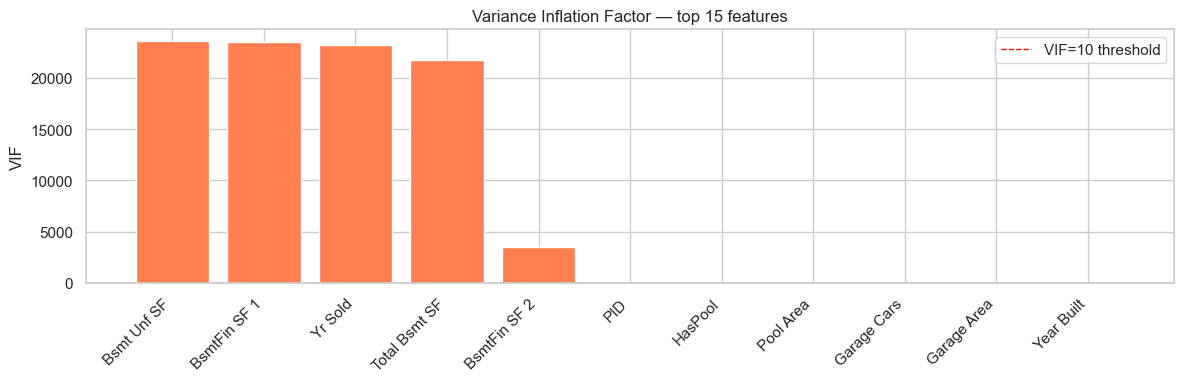

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

num_X = X.select_dtypes(include=[np.number]).dropna(axis=1)
num_X = num_X.loc[:, num_X.nunique() > 1]

vif_data = pd.DataFrame({
    'Feature': num_X.columns,
    'VIF': [variance_inflation_factor(num_X.values, i) for i in range(num_X.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('Features with VIF > 10:')
print(vif_data[vif_data['VIF'] > 10].head(15).to_string(index=False))

top_vif = vif_data.head(15)
plt.figure(figsize=(12, 4))
plt.bar(top_vif['Feature'], top_vif['VIF'],
        color=['coral' if v > 10 else 'steelblue' for v in top_vif['VIF']],
        edgecolor='white')
plt.axhline(10, color='red', linestyle='--', linewidth=1, label='VIF=10 threshold')
plt.title('Variance Inflation Factor — top 15 features')
plt.ylabel('VIF')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/vif_bar.png')
plt.show()

## 6. Feature importance — Quick Random Forest

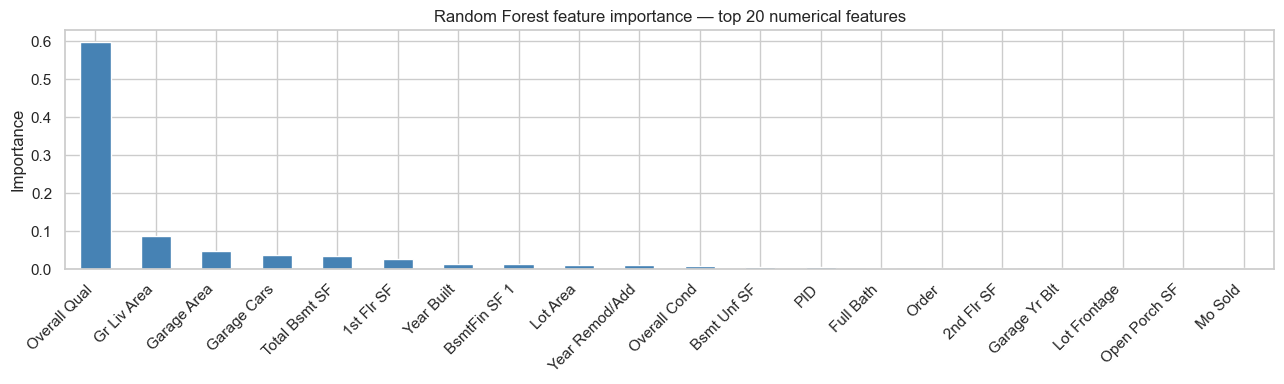


Top 10:
Overall Qual      0.5980
Gr Liv Area       0.0858
Garage Area       0.0468
Garage Cars       0.0380
Total Bsmt SF     0.0339
1st Flr SF        0.0264
Year Built        0.0133
BsmtFin SF 1      0.0125
Lot Area          0.0117
Year Remod/Add    0.0097


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_cols_list = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_list = X.select_dtypes(include='object').columns.tolist()

rf = Pipeline([
    ('prep', ColumnTransformer([
        ('num', 'passthrough', num_cols_list),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_list)
    ])),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
rf.fit(X, np.log1p(y_aligned))

importances = rf.named_steps['model'].feature_importances_
num_imp = pd.Series(importances[:len(num_cols_list)], index=num_cols_list).sort_values(ascending=False)

plt.figure(figsize=(13, 4))
num_imp.head(20).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Random Forest feature importance — top 20 numerical features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/rf_feature_importance.png')
plt.show()

print('\nTop 10:')
print(num_imp.head(10).round(4).to_string())